In [1]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

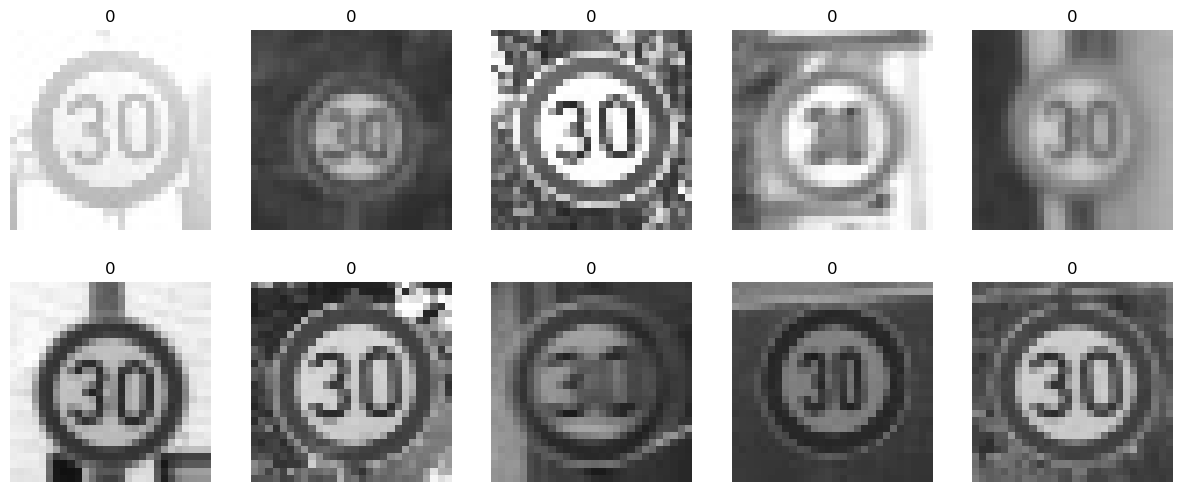

In [2]:
folder = 'Downloads/subset_lecture'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

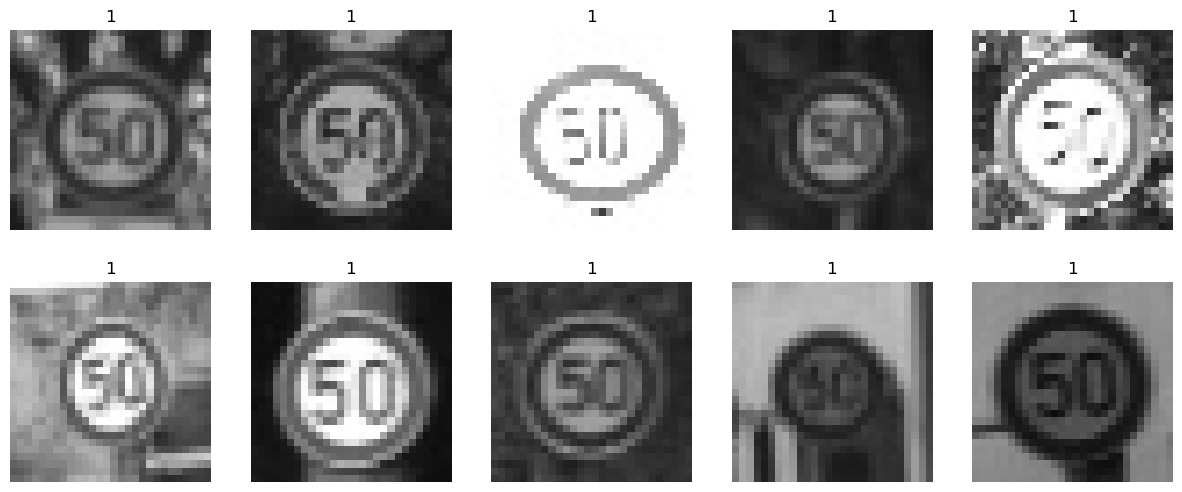

In [3]:
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [4]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


In [5]:
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


In [6]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.037549495697021484


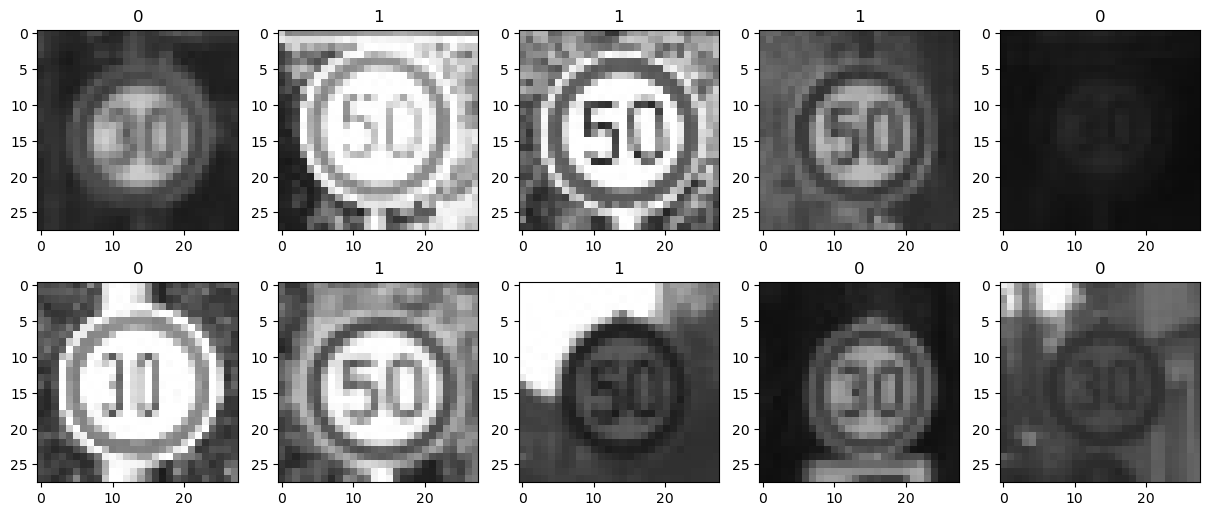

In [7]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

In [8]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

C:\Users\User\anaconda3\envs\cv\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [9]:
inputs = Input(shape=(pixels.shape[1],))
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
print(pixels.shape)

(4470, 784)


In [11]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

In [12]:
history = model.fit(pixels, labels, epochs=100, batch_size=32)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2900
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2117
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1773
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1536
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1390
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1233
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1134
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1095
Epoch 9/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1040
Epoch 10/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0973
Epoch 11/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0974
Epoch 12/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0927
Epoch 13/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0887
Epoch 14/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0868
Epoch 15/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

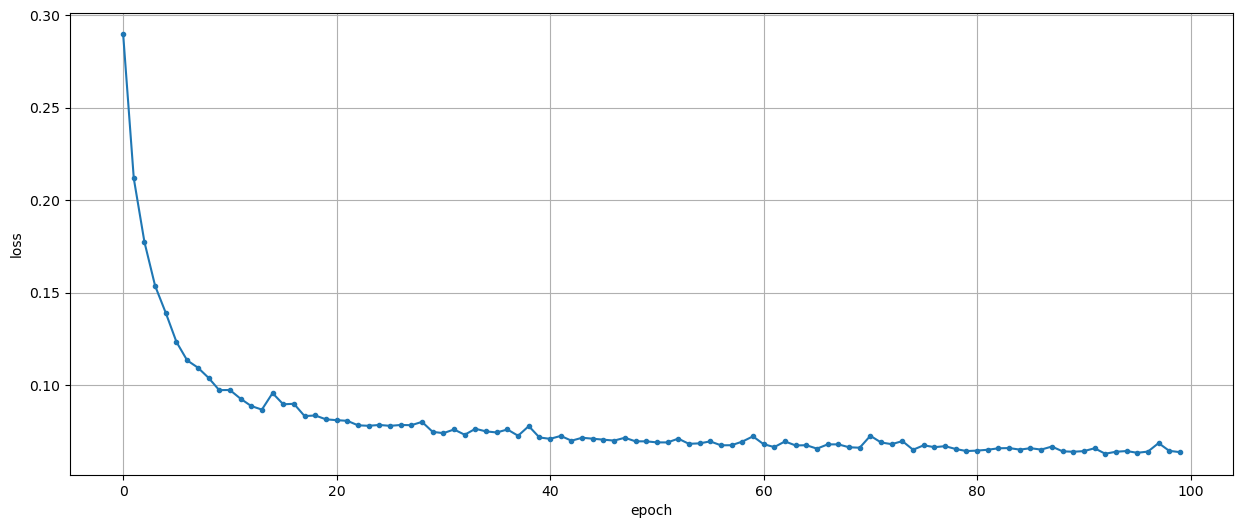

In [13]:
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[0.5302239] [0.5302239]


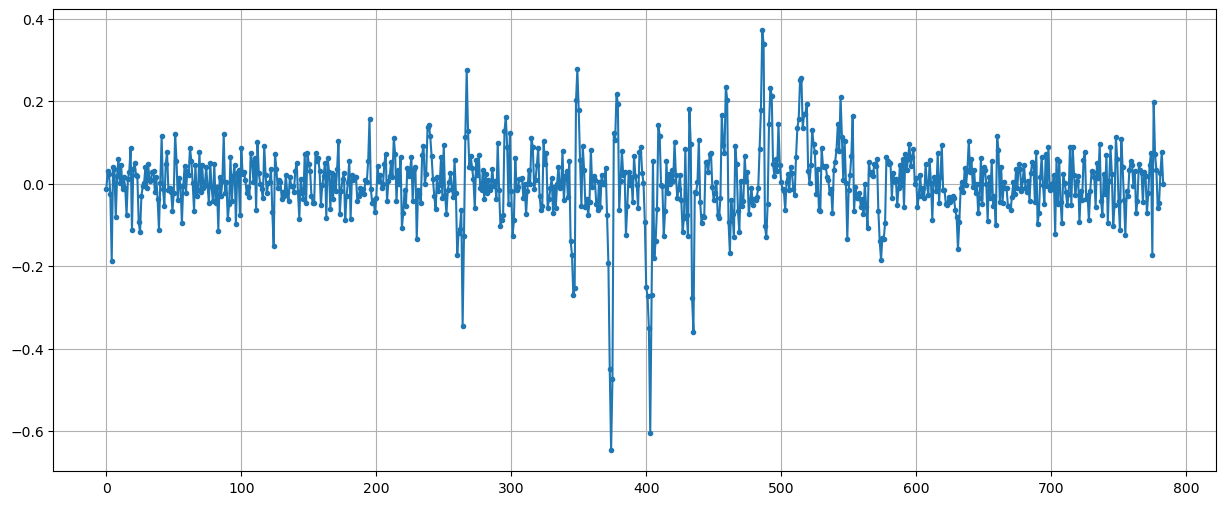

In [14]:
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

In [18]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.3868337]] 0


In [19]:
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step


In [20]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9695749440715884


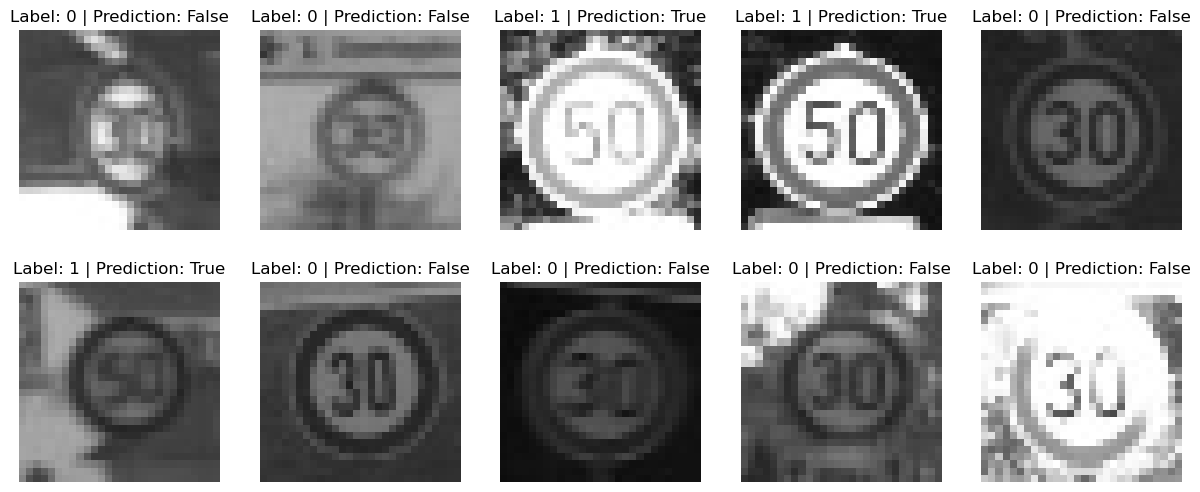

In [21]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)): 
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)

In [22]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense

inputs = Input(shape=(pixels.shape[1],))
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,353 (204.50 KB)

 Trainable params: 52,353 (204.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    pixels,
    labels,
    epochs=100,
    batch_size=32,
    validation_split=0.2
    )

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9306 - loss: 0.1436 - val_accuracy: 0.9620 - val_loss: 0.1047
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9315 - loss: 0.1456 - val_accuracy: 0.9609 - val_loss: 0.1080
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9474 - loss: 0.1364 - val_accuracy: 0.9720 - val_loss: 0.0989
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9231 - loss: 0.1783 - val_accuracy: 0.9586 - val_loss: 0.1280
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9318 - loss: 0.1507 - val_accuracy: 0.9687 - val_loss: 0.1004
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9382 - loss: 0.1373 - val_accuracy: 0.9642 - val_loss: 0.1298
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9452 - loss: 0.1280 - val_accuracy: 0.9687 - val_loss: 0.0995
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9402 - loss: 0.1344 - val_accu

In [36]:
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [37]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9742729306487695


In [31]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Dropout

inputs = Input(shape=(pixels.shape[1],))
x = Dense(128, activation='relu')(inputs)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    pixels,
    labels,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

model.summary()

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6342 - loss: 0.6474 - val_accuracy: 0.6980 - val_loss: 0.5922
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7559 - loss: 0.5266 - val_accuracy: 0.8277 - val_loss: 0.4404
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8303 - loss: 0.4163 - val_accuracy: 0.8937 - val_loss: 0.3191
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8579 - loss: 0.3428 - val_accuracy: 0.9016 - val_loss: 0.2717
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8867 - loss: 0.3026 - val_accuracy: 0.9128 - val_loss: 0.2330
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9010 - loss: 0.2663 - val_accuracy: 0.9083 - val_loss: 0.2310
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9139 - loss: 0.2266 - val_accuracy: 0.9284 - val_loss: 0.2093
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9080 - loss: 0.2410 - val_accu

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,405 (1.25 MB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 217,604 (850.02 KB)

In [32]:
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [33]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9765100671140939


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

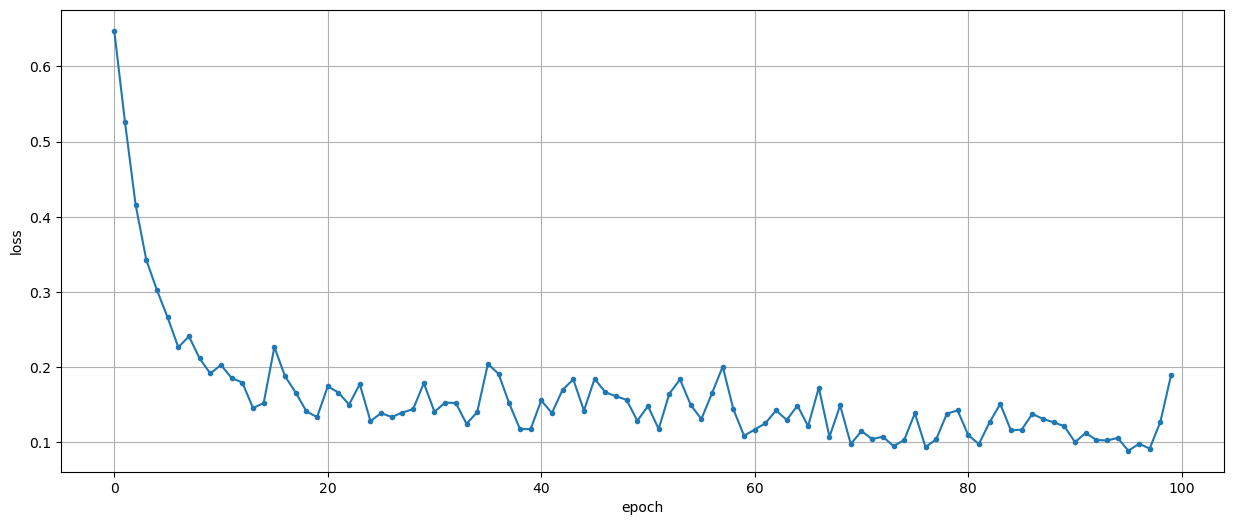

In [34]:
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

In [ ]:
#I couldn't get a result better than 1 percent +/- ):